# Load Data

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.model_selection import train_test_split

df = pd.read_csv('files/BirthRate&Maternal.csv')
df['Date'] = pd.to_datetime(df['Year and Month'], format='%B %Y')
df['Ordinal_Date'] = df['Date'].map(pd.Timestamp.toordinal)
# Load dataset and derive date features
# Ordinal dates keep ordering but not equal intervals

print(f"Total data points: {len(df)} months")
df.head()
df.describe()

Total data points: 72 months


,Male,Female,Total,Maternal death,Date,Ordinal_Date
count,72.000000,72.000000,72.000000,72.000000,72,72.000000
mean,21706.569444,20387.777778,42094.347222,82.388889,2022-12-16 06:40:00,738505.277778
min,15290.000000,14388.000000,29678.000000,58.000000,2020-01-01 00:00:00,737425.000000
25%,19680.500000,18402.500000,38164.000000,74.750000,2021-06-23 12:00:00,737964.500000
50%,21608.000000,20318.000000,41926.000000,82.000000,2022-12-16 12:00:00,738505.500000
75%,24215.750000,22845.250000,47061.000000,92.000000,2024-06-08 12:00:00,739045.500000
max,28029.000000,26170.000000,54199.000000,106.000000,2025-12-01 00:00:00,739586.000000
std,2978.872699,2803.411529,5778.335876,11.372757,NaN,636.992963


# Data visualization

C:\TEMP\ipykernel_8224\1303671052.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Year', y='Total', data=df, palette='muted')


   Year   Total  Growth Rate (%)  Gender Ratio (M/F)
0  2020  587368              NaN            1.064330
1  2021  544570        -7.286403            1.062617
2  2022  502107        -7.797528            1.070126
3  2023  517934         3.152117            1.059314
4  2024  462240       -10.753108            1.065665
5  2025  416574        -9.879283            1.066965


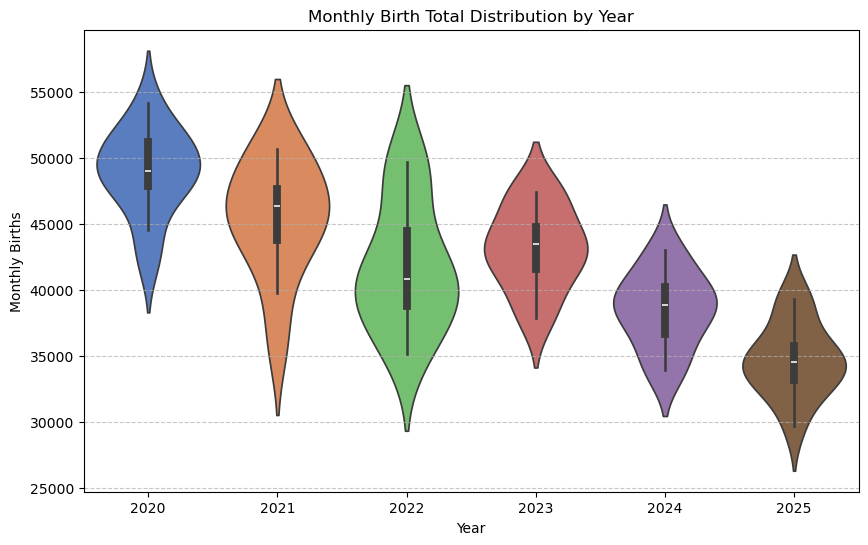

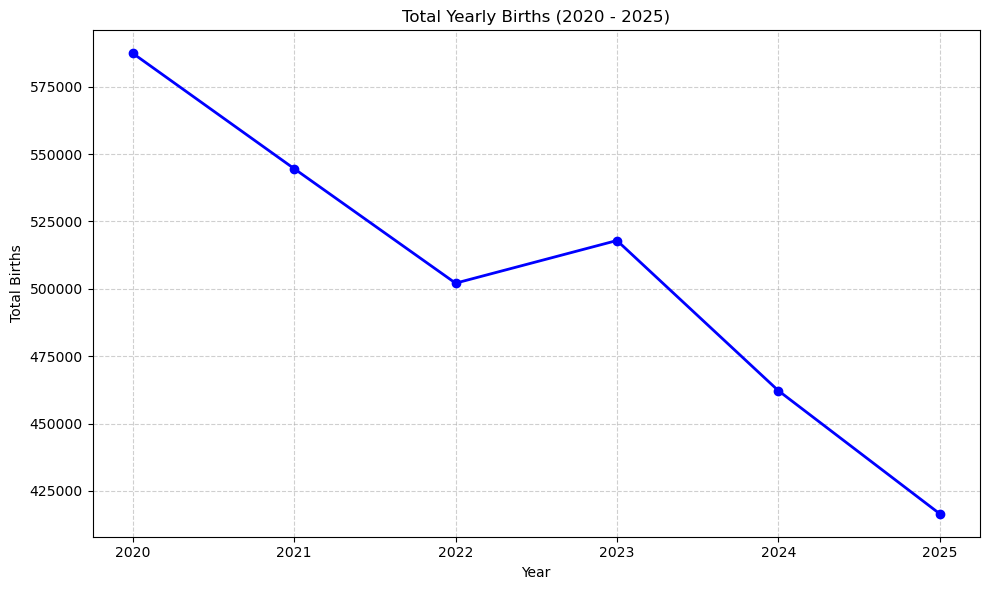

In [ ]:
df['Year'] = df['Year and Month'].apply(lambda x: int(x.split()[-1]))
yearly_data = df.groupby('Year').agg({
    'Total': 'sum',
    'Male': 'sum',
    'Female': 'sum'
}).reset_index()
# Visualize yearly totals, growth, and distributions

# Growth Rate and Gender Ratio
yearly_data['Growth Rate (%)'] = yearly_data['Total'].pct_change() * 100
yearly_data['Gender Ratio (M/F)'] = yearly_data['Male'] / yearly_data['Female']

# Violin Plot
plt.figure(figsize=(10, 6))
sns.violinplot(x='Year', y='Total', data=df, palette='muted')
plt.title('Monthly Birth Total Distribution by Year')
plt.ylabel('Monthly Births')
plt.xlabel('Year')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Line Plot
plt.figure(figsize=(10, 6))
plt.plot(yearly_data['Year'], yearly_data['Total'], marker='o', color='b', linewidth=2)
plt.title('Total Yearly Births (2020 - 2025)')
plt.ylabel('Total Births')
plt.xlabel('Year')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()

# Displaying calculated stats
print(yearly_data[['Year', 'Total', 'Growth Rate (%)', 'Gender Ratio (M/F)']])

# Train/Test Splitting & Feature Scaling

In [ ]:
train, test = train_test_split(df, test_size=0.2, shuffle=False)
# Split data in time order

# Setup Scaler and Transform Data

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train[['Ordinal_Date']])
X_test_scaled = scaler.transform(test[['Ordinal_Date']])
# Scale date feature for distance-based models

# Setup Future Dates

In [ ]:
future_dates = pd.date_range(start=df['Date'].max() + pd.DateOffset(months=1), periods=24, freq='MS')
future_ordinals = np.array([d.toordinal() for d in future_dates]).reshape(-1, 1)
future_scaled = scaler.transform(future_ordinals)
# Prepare future months for forecasting

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


# Initialize Models and Plotting

C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\User\anacon

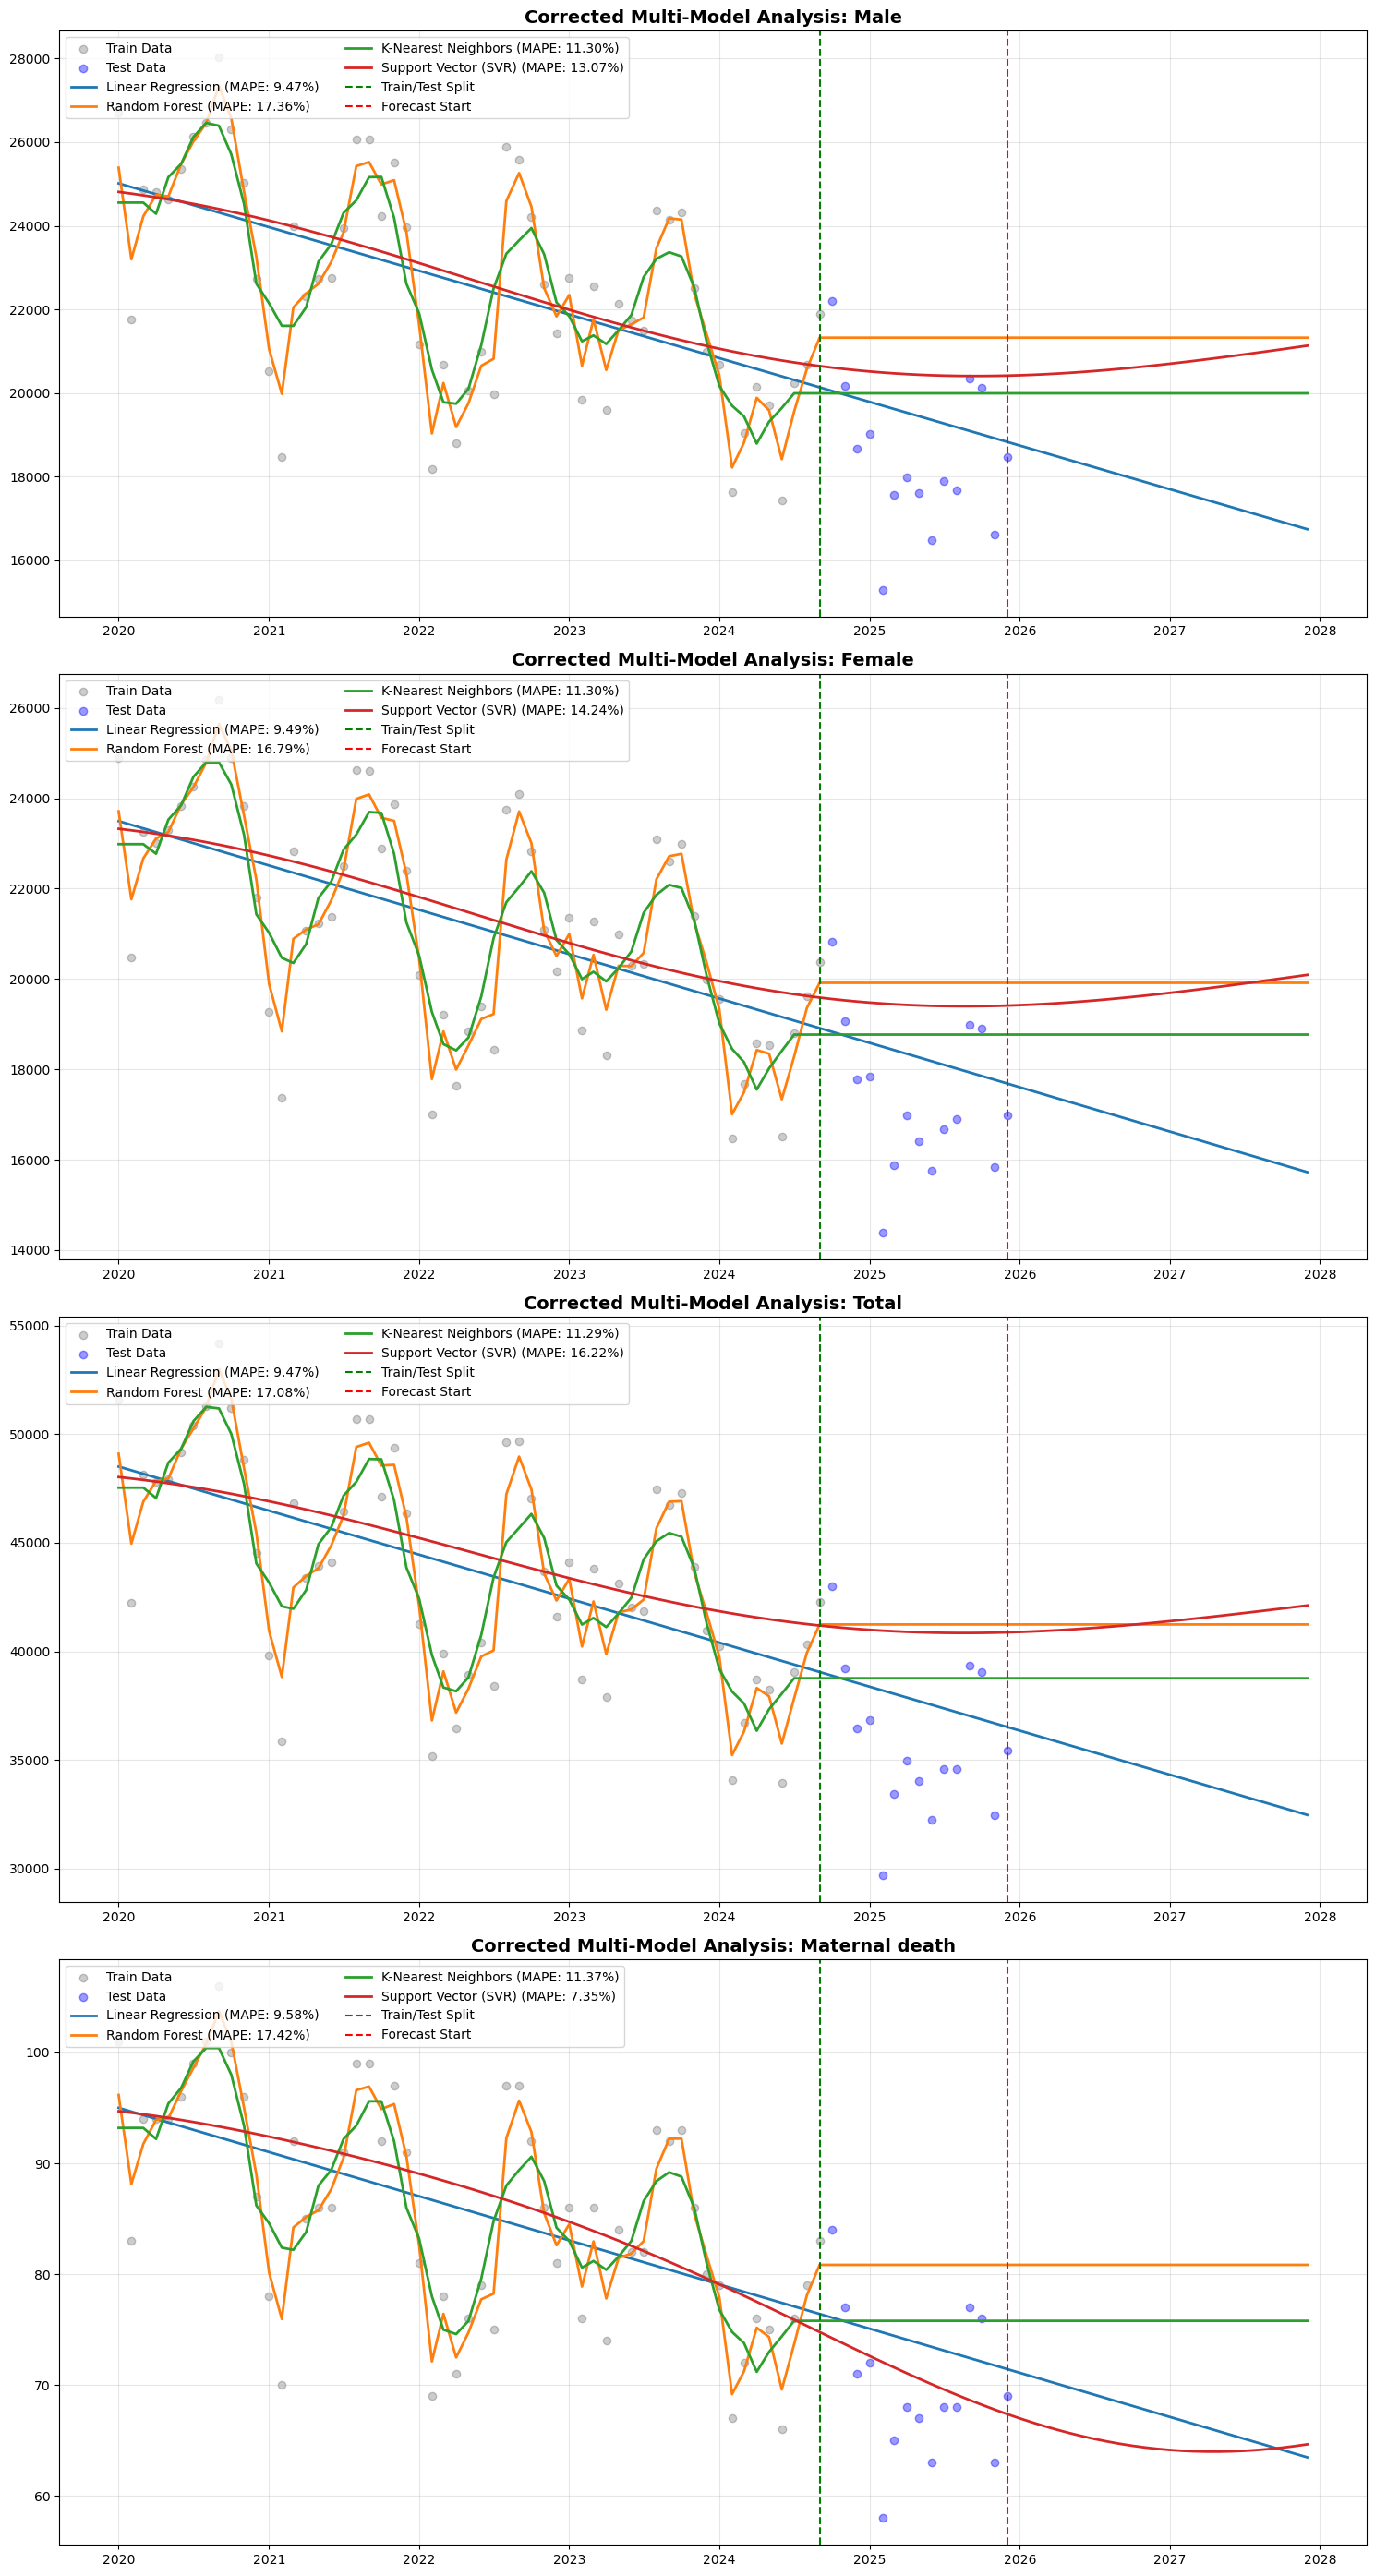

In [ ]:
fig, axes = plt.subplots(4, 1, figsize=(15, 28))
error_results = []
targets = ['Male', 'Female', 'Total', 'Maternal death']
# Train models per target and plot forecasts

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'K-Nearest Neighbors': KNeighborsRegressor(n_neighbors=5),
    'Support Vector (SVR)': SVR(kernel='rbf', C=1e3, gamma=0.1)
}

for idx, target in enumerate(targets):
    y_train = train[target]
    y_test = test[target]
    
    # Plot historical dots
    axes[idx].scatter(train['Date'], y_train, color='black', alpha=0.2, label='Train Data')
    axes[idx].scatter(test['Date'], y_test, color='blue', alpha=0.4, label='Test Data')
    
    for name, model in models.items():
        # Select scaled or raw features
        if name in ['Support Vector (SVR)', 'K-Nearest Neighbors']:
            X_tr, X_ts, X_ft = X_train_scaled, X_test_scaled, future_scaled
        else:
            X_tr, X_ts, X_ft = train[['Ordinal_Date']], test[['Ordinal_Date']], future_ordinals
            
        # Train and Predict
        model.fit(X_tr, y_train)
        
        # Predictions for error calculation (on test set) and plotting
        p_train = model.predict(X_tr)
        p_test = model.predict(X_ts)
        p_future = model.predict(X_ft)
        
        # Calculate MAPE correctly on the unseen Test data
        mape = mean_absolute_percentage_error(y_test, p_test) * 100
        
        # FIX: Combine components to create matching dimensions for x and y
        all_dates = np.concatenate([train['Date'].values, test['Date'].values, future_dates.values])
        all_preds = np.concatenate([p_train, p_test, p_future])
        
        # This will now have the same shape: (len(df) + 24,)
        axes[idx].plot(all_dates, all_preds, label=f'{name} (MAPE: {mape:.2f}%)', linewidth=2)
        error_results.append({'Target': target, 'Model': name, 'Error %': round(mape, 2)})
    
    # Formatting
    axes[idx].axvline(train['Date'].max(), color='green', linestyle='--', label='Train/Test Split')
    axes[idx].axvline(test['Date'].max(), color='red', linestyle='--', label='Forecast Start')
    axes[idx].set_title(f'Corrected Multi-Model Analysis: {target}', fontsize=14, fontweight='bold')
    axes[idx].legend(loc='upper left', ncol=2)
    axes[idx].grid(True, alpha=0.3)
    plt.savefig('Predict Result.png')

plt.tight_layout()
plt.show()

# Error calculating

In [ ]:
error_df = pd.DataFrame(error_results).pivot(index='Target', columns='Model', values='Error %')
print("\n--- Model Accuracy Summary (MAPE %) ---")
error_df
# Summarize model errors (MAPE)


--- Model Accuracy Summary (MAPE %) ---


Model,K-Nearest Neighbors,Linear Regression,Random Forest,Support Vector (SVR)
Target,,,,
Female,11.30,9.49,16.79,14.24
Male,11.30,9.47,17.36,13.07
Maternal death,11.37,9.58,17.42,7.35
Total,11.29,9.47,17.08,16.22
